# Optimización de Precios y Ocupación en el Mercado de Alquileres Temporarios
## Análisis de Airbnb en la Ciudad Autónoma de Buenos Aires

**Data Science II — Machine Learning para la Ciencia de Datos**
**Primera Entrega — Obtención de insights a partir de visualizaciones**


## Abstracto: motivación y audiencia

**Motivación.** El alquiler temporario (Airbnb y plataformas similares) es hoy una de las
formas más dinámicas de explotación inmobiliaria en las grandes ciudades. A diferencia del
alquiler tradicional, el precio "correcto" de una propiedad de alquiler temporario depende de
variables muy específicas del negocio turístico: ubicación relativa a puntos de interés,
comodidades ofrecidas, reputación acumulada (reviews) y estacionalidad. Fijar un precio por
debajo o por encima del punto óptimo tiene un costo directo: precios muy altos generan baja
ocupación, precios muy bajos resignan rentabilidad.

Este proyecto analiza más de 29.000 publicaciones activas de Airbnb en la Ciudad Autónoma de
Buenos Aires (CABA), enriquecidas con datos de OpenStreetMap sobre la oferta gastronómica y de
transporte público de cada barrio, para entender **qué factores explican el precio y la
ocupación** de una propiedad.

**Audiencia.** El análisis está dirigido a **inversores inmobiliarios y gestores de
propiedades de alquiler temporario** que evalúan en qué barrio comprar/alquilar una unidad,
cómo equiparla y cómo fijar precio, sin necesidad de conocimientos técnicos de estadística o
programación.


## Preguntas / Hipótesis a responder

1. **¿Cómo impacta la densidad de puntos de interés (restaurantes/bares y transporte) en el
   precio base de la propiedad?** Hipótesis: los barrios con mayor densidad de oferta
   gastronómica y transporte público concentran precios promedio más altos.

2. **¿Existe una correlación directa entre las valoraciones (reviews) y la tarifa promedio
   diaria?** Hipótesis: a mayor puntaje de reviews, mayor es el precio que el mercado
   convalida (el host puede "cobrar" su reputación).

3. **¿Qué comodidades (amenities) generan un premium real en el precio de alquiler?**
   Hipótesis: comodidades de alto valor percibido (pileta, aire acondicionado, cochera) generan
   un incremento de precio significativo frente a propiedades que no las ofrecen.


## 1. Obtención de datos

Se combinan dos fuentes públicas:

- **Inside Airbnb** (https://insideairbnb.com): dataset detallado de publicaciones activas de
  Airbnb en CABA (scrape del 29/06/2026), descargado directamente vía HTTP en formato CSV.
- **OpenStreetMap / Overpass API** (https://overpass-api.de): API pública y gratuita que permite
  consultar puntos de interés geográficos. Se utiliza para calcular, por barrio, la cantidad de
  locales gastronómicos y de paradas/estaciones de transporte público cercanas al centroide de
  las publicaciones de ese barrio.

Los bloques de descarga guardan los datos crudos en archivos locales (`data/*.csv`) para que el
resto del notebook pueda ejecutarse sin volver a golpear las APIs.


In [1]:
import json
import time
import warnings

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 60)


### 1.1 Dataset base: Inside Airbnb (CABA)

Se descarga el archivo detallado de publicaciones (90 columnas: precio, ubicación, huésped
máximo, amenities, puntajes de reviews, disponibilidad, etc.) directamente desde el servidor de
Inside Airbnb y se guarda una copia local.


In [2]:
AIRBNB_URL = (
    "https://data.insideairbnb.com/argentina/ciudad-aut%C3%B3noma-de-buenos-aires/"
    "buenos-aires/2026-06-29/data/listings.csv.gz"
)
LOCAL_RAW_PATH = "data/listings_raw_cache.csv.gz"

# Descarga desde la API pública. Se puede comentar esta celda luego de la primera
# ejecución y cargar directamente el archivo local guardado en LOCAL_RAW_PATH.
listings_raw = pd.read_csv(AIRBNB_URL, compression="gzip", low_memory=False)
listings_raw.to_csv(LOCAL_RAW_PATH, index=False, compression="gzip")

print(f"Publicaciones descargadas: {listings_raw.shape[0]:,}")
print(f"Columnas: {listings_raw.shape[1]}")


Publicaciones descargadas: 29,685
Columnas: 90


### 1.2 Enriquecimiento con OpenStreetMap (Overpass API)

Para responder la Pregunta 1 (densidad de puntos de interés) se calcula, para cada uno de los
48 barrios de CABA, un centroide (promedio de latitud/longitud de las publicaciones de ese
barrio) y se consulta a la Overpass API cuántos locales gastronómicos (restaurantes, cafés,
bares, comida rápida) y puntos de transporte público (paradas de colectivo, estaciones de
subte/tren) hay en un radio de 900 metros.

Esta celda ya fue ejecutada y el resultado se guardó en `data/poi_density_by_barrio.csv`.
Como la API pública de Overpass es de uso gratuito y compartido (rate-limited), la celda de
descarga queda comentada por defecto; se puede reactivar cambiando `RUN_OVERPASS = True`.


In [3]:
RUN_OVERPASS = False  # cambiar a True para volver a consultar la API en vivo
POI_CACHE_PATH = "data/poi_density_by_barrio.csv"

OVERPASS_URL = "https://overpass-api.de/api/interpreter"
HEADERS = {"User-Agent": "TP-DataScienceII-Airbnb-BsAs/1.0 (proyecto educativo)"}
RADIUS_M = 900


def poi_count(lat, lon, radius=RADIUS_M, max_retries=3):
    query_gastro = f"""
    [out:json][timeout:25];
    (
      node[amenity=restaurant](around:{radius},{lat},{lon});
      node[amenity=cafe](around:{radius},{lat},{lon});
      node[amenity=bar](around:{radius},{lat},{lon});
      node[amenity=fast_food](around:{radius},{lat},{lon});
    );
    out count;
    """
    query_transporte = f"""
    [out:json][timeout:25];
    (
      node[highway=bus_stop](around:{radius},{lat},{lon});
      node[railway=station](around:{radius},{lat},{lon});
      node[station=subway](around:{radius},{lat},{lon});
    );
    out count;
    """
    counts = {}
    for label, q in [("gastronomia", query_gastro), ("transporte", query_transporte)]:
        for attempt in range(max_retries):
            try:
                r = requests.get(OVERPASS_URL, params={"data": q}, headers=HEADERS, timeout=35)
                r.raise_for_status()
                counts[label] = int(r.json()["elements"][0]["tags"]["total"])
                break
            except Exception as e:
                if attempt == max_retries - 1:
                    counts[label] = None
                else:
                    time.sleep(3)
        time.sleep(1.2)
    return counts


if RUN_OVERPASS:
    centroids = (
        listings_raw.groupby("neighbourhood_cleansed")[["latitude", "longitude"]]
        .mean()
        .reset_index()
        .rename(columns={"neighbourhood_cleansed": "barrio"})
    )
    rows = []
    for _, row in centroids.iterrows():
        counts = poi_count(row["latitude"], row["longitude"])
        rows.append({
            "barrio": row["barrio"],
            "poi_gastronomia_900m": counts["gastronomia"],
            "poi_transporte_900m": counts["transporte"],
        })
    poi_density = pd.DataFrame(rows)
    poi_density["poi_total_900m"] = (
        poi_density["poi_gastronomia_900m"] + poi_density["poi_transporte_900m"]
    )
    poi_density.to_csv(POI_CACHE_PATH, index=False)
else:
    poi_density = pd.read_csv(POI_CACHE_PATH)

poi_density.sort_values("poi_total_900m", ascending=False).head(10)


,barrio,lat_centroide,lon_centroide,poi_gastronomia_900m,poi_transporte_900m,poi_total_900m
22,San Nicolas,-34.603475,-58.382265,449.0,219.0,668.0
34,Belgrano,-34.559154,-58.455024,448.0,132.0,580.0
11,Monserrat,-34.612718,-58.378723,336.0,214.0,550.0
19,Retiro,-34.594986,-58.379969,303.0,220.0,523.0
14,Palermo,-34.582583,-58.427255,354.0,130.0,484.0
6,Constitucion,-34.621118,-58.381923,149.0,228.0,377.0
24,Villa Crespo,-34.596980,-58.438694,142.0,154.0,296.0
4,Chacarita,-34.586021,-58.448615,122.0,160.0,282.0
33,Almagro,-34.605077,-58.422260,106.0,138.0,244.0
1,Barracas,-34.632817,-58.374999,42.0,190.0,232.0


## 2. Limpieza y transformación de datos

Se parte del dataset crudo de 90 columnas y se construye un dataset analítico con:

- **Precio limpio** (`price` viene como texto, ej. `"$86,206.29"`).
- **Filtrado de outliers extremos** de precio (fuera del percentil 1–99, valores que
  corresponden a errores de carga o publicaciones no representativas).
- **Amenities parseadas** desde el campo de texto tipo lista a columnas binarias para las
  comodidades más relevantes, y un conteo total de amenities.
- **Proxy de ocupación**: `estimated_occupancy_l365d` (noches ocupadas estimadas en los últimos
  365 días, ya provisto por Inside Airbnb a partir del historial de reviews y disponibilidad).
- **Cruce con densidad de POI por barrio** (dataset enriquecido en la sección 1.2).


In [4]:
df = listings_raw.copy()

# --- precio ---
df["price_clean"] = (
    df["price"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False)
)
df["price_clean"] = pd.to_numeric(df["price_clean"], errors="coerce")

# --- filtro de calidad: precio valido, al menos 1 huesped, no son estadias de largo plazo ---
p1, p99 = df["price_clean"].quantile([0.01, 0.99])
df = df[
    df["price_clean"].notna()
    & df["price_clean"].between(p1, p99)
    & (df["accommodates"] > 0)
    & (df["minimum_nights"] <= 30)
].copy()

print(f"Filas antes de limpiar: {listings_raw.shape[0]:,}")
print(f"Filas luego de limpiar: {df.shape[0]:,}")
print(f"Rango de precios analizado: ${p1:,.0f} - ${p99:,.0f} ARS/noche")


Filas antes de limpiar: 29,685
Filas luego de limpiar: 27,166
Rango de precios analizado: $22,449 - $811,998 ARS/noche


In [5]:
# --- amenities: de texto tipo lista a columnas binarias ---
def parse_amenities(raw):
    try:
        return json.loads(raw)
    except Exception:
        return []

df["amenities_list"] = df["amenities"].apply(parse_amenities)
df["n_amenities"] = df["amenities_list"].apply(len)

amenities_clave = {
    "tiene_wifi": "Wifi",
    "tiene_pileta": "Pool",
    "tiene_aire_acondicionado": "Air conditioning",
    "tiene_cochera": "parking",
    "tiene_cocina": "Kitchen",
    "tiene_ascensor": "Elevator",
    "tiene_gimnasio": "Gym",
    "acepta_mascotas": "Pets allowed",
}
for col, keyword in amenities_clave.items():
    df[col] = df["amenities_list"].apply(
        lambda lst: any(keyword.lower() in a.lower() for a in lst)
    )

df[list(amenities_clave.keys()) + ["n_amenities"]].mean(numeric_only=True).round(2)


tiene_wifi                   0.99
tiene_pileta                 0.27
tiene_aire_acondicionado     0.70
tiene_cochera                0.56
tiene_cocina                 0.94
tiene_ascensor               0.61
tiene_gimnasio               0.13
acepta_mascotas              0.19
n_amenities                 32.87
dtype: float64

In [6]:
# --- ocupacion y reviews ---
df["ocupacion_pct_365d"] = (df["estimated_occupancy_l365d"] / 365 * 100).clip(0, 100)
df["tiene_reviews"] = df["number_of_reviews"] > 0

# --- cruce con densidad de POI por barrio ---
df = df.rename(columns={"neighbourhood_cleansed": "barrio"})
df = df.merge(
    poi_density[["barrio", "poi_gastronomia_900m", "poi_transporte_900m", "poi_total_900m"]],
    on="barrio",
    how="left",
)

# --- dataset final para el analisis, guardado localmente ---
cols_analisis = [
    "id", "barrio", "latitude", "longitude", "room_type", "property_type",
    "accommodates", "bedrooms", "beds", "price_clean", "minimum_nights",
    "number_of_reviews", "review_scores_rating", "review_scores_location",
    "review_scores_value", "estimated_occupancy_l365d", "ocupacion_pct_365d",
    "n_amenities", "poi_gastronomia_900m", "poi_transporte_900m", "poi_total_900m",
    "instant_bookable", "host_is_superhost",
] + list(amenities_clave.keys())

df_analisis = df[cols_analisis].copy()
df_analisis.to_csv("data/airbnb_baires_analitico.csv", index=False)
df_analisis.to_json("data/airbnb_baires_analitico.json", orient="records", indent=2)

df_analisis.head()


,id,barrio,latitude,longitude,room_type,property_type,accommodates,bedrooms,beds,price_clean,minimum_nights,number_of_reviews,review_scores_rating,review_scores_location,review_scores_value,estimated_occupancy_l365d,ocupacion_pct_365d,n_amenities,poi_gastronomia_900m,poi_transporte_900m,poi_total_900m,instant_bookable,host_is_superhost,tiene_wifi,tiene_pileta,tiene_aire_acondicionado,tiene_cochera,tiene_cocina,tiene_ascensor,tiene_gimnasio,acepta_mascotas
0,54019695,Puerto Madero,-34.605030,-58.366250,Entire home/apt,Entire rental unit,3,1.0,2.0,86206.29,14.0,0,NaN,NaN,NaN,0,0.000000,5,139.0,64.0,203.0,NaN,t,True,True,True,True,False,False,False,False
1,41720307,Recoleta,-34.592250,-58.396620,Entire home/apt,Entire rental unit,2,1.0,1.0,74564.86,2.0,9,4.56,4.67,4.56,24,6.575342,23,NaN,NaN,NaN,NaN,f,True,False,True,False,True,True,False,False
2,1482653002662185299,Recoleta,-34.596220,-58.396290,Entire home/apt,Entire rental unit,4,2.0,3.0,144486.00,2.0,19,4.84,4.89,4.89,114,31.232877,7,NaN,NaN,NaN,NaN,t,True,False,True,False,True,False,False,False
3,1046394538968941382,Almagro,-34.598156,-58.420211,Private room,Private room in rental unit,1,NaN,1.0,25317.00,1.0,0,NaN,NaN,NaN,0,0.000000,3,106.0,138.0,244.0,NaN,f,False,False,False,False,True,False,False,False
4,1708343918490071398,Palermo,-34.587984,-58.429060,Entire home/apt,Entire serviced apartment,2,NaN,1.0,60746.92,2.0,0,NaN,NaN,NaN,0,0.000000,8,354.0,130.0,484.0,NaN,f,True,False,True,False,True,False,False,False


## 3. Análisis Exploratorio de Datos (EDA)

### 3.0 Resumen general del dataset


In [7]:
print(f"Filas: {df_analisis.shape[0]:,}  |  Columnas: {df_analisis.shape[1]}")
print()
print("Tipos de datos:")
print(df_analisis.dtypes.value_counts())
print()
resumen_metadata = pd.DataFrame({
    "tipo": df_analisis.dtypes.astype(str),
    "% nulos": (df_analisis.isna().mean() * 100).round(1),
    "valores_unicos": df_analisis.nunique(),
})
resumen_metadata.to_csv("data/resumen_metadata.csv")
resumen_metadata


Filas: 27,166  |  Columnas: 31

Tipos de datos:
float64    14
bool        8
int64       5
str         4
Name: count, dtype: int64



,tipo,% nulos,valores_unicos
id,int64,0.0,27166
barrio,str,0.0,48
latitude,float64,0.0,17620
longitude,float64,0.0,18962
room_type,str,0.0,4
property_type,str,0.0,51
accommodates,int64,0.0,16
bedrooms,float64,17.6,18
beds,float64,3.6,29
price_clean,float64,0.0,18653


In [8]:
df_analisis["price_clean"].describe().round(0)


count     27166.0
mean     123358.0
std       87162.0
min       22450.0
25%       75948.0
50%      100964.0
75%      139234.0
max      811877.0
Name: price_clean, dtype: float64

### 3.1 Pregunta 1 — Densidad de puntos de interés vs. precio

¿Los barrios con más oferta gastronómica y de transporte público cercano tienen precios
promedio más altos?


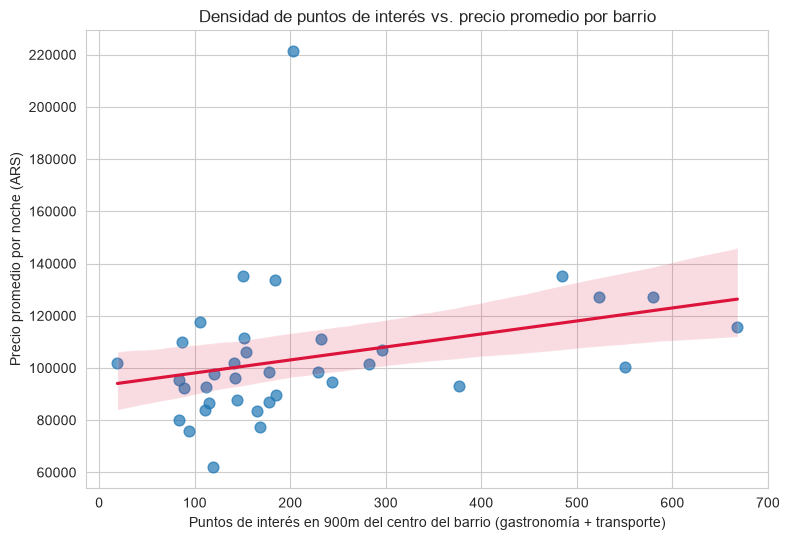

Correlación (barrio): densidad de POI vs. precio promedio = 0.30


In [9]:
precio_por_barrio = (
    df_analisis.groupby("barrio")
    .agg(precio_promedio=("price_clean", "mean"), publicaciones=("price_clean", "size"))
    .join(poi_density.set_index("barrio"))
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.regplot(
    data=precio_por_barrio, x="poi_total_900m", y="precio_promedio",
    scatter_kws={"s": 60, "alpha": 0.7}, line_kws={"color": "crimson"}, ax=ax,
)
ax.set_xlabel("Puntos de interés en 900m del centro del barrio (gastronomía + transporte)")
ax.set_ylabel("Precio promedio por noche (ARS)")
ax.set_title("Densidad de puntos de interés vs. precio promedio por barrio")
plt.tight_layout()
plt.savefig("data/fig_poi_vs_precio.png", dpi=150)
plt.show()

corr = precio_por_barrio["poi_total_900m"].corr(precio_por_barrio["precio_promedio"])
print(f"Correlación (barrio): densidad de POI vs. precio promedio = {corr:.2f}")


**Lectura:** cada punto es un barrio de CABA. Una correlación positiva indica que los
barrios mejor "equipados" en oferta gastronómica y de transporte —típicamente los barrios
turísticos y céntricos— sostienen precios promedio más altos. *(La celda de arriba calcula el
coeficiente de correlación real sobre los datos.)*


### 3.2 Pregunta 2 — Reviews vs. tarifa promedio diaria

¿Las propiedades mejor valoradas cobran tarifas más altas?


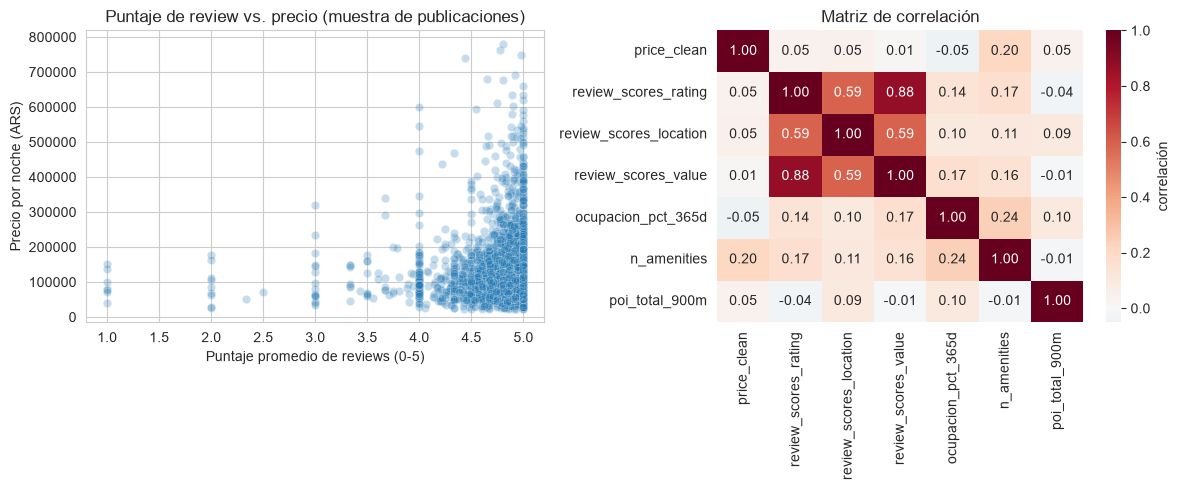

Correlación puntaje de reviews vs. precio = 0.05


In [10]:
con_reviews = df_analisis[df_analisis["review_scores_rating"].notna()]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    data=con_reviews.sample(min(4000, len(con_reviews)), random_state=42),
    x="review_scores_rating", y="price_clean", alpha=0.25, ax=axes[0],
)
axes[0].set_title("Puntaje de review vs. precio (muestra de publicaciones)")
axes[0].set_xlabel("Puntaje promedio de reviews (0-5)")
axes[0].set_ylabel("Precio por noche (ARS)")

corr_cols = [
    "price_clean", "review_scores_rating", "review_scores_location",
    "review_scores_value", "ocupacion_pct_365d", "n_amenities", "poi_total_900m",
]
sns.heatmap(
    con_reviews[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1],
    cbar_kws={"label": "correlación"},
)
axes[1].set_title("Matriz de correlación")

plt.tight_layout()
plt.savefig("data/fig_reviews_vs_precio.png", dpi=150)
plt.show()

corr_rp = con_reviews["review_scores_rating"].corr(con_reviews["price_clean"])
print(f"Correlación puntaje de reviews vs. precio = {corr_rp:.2f}")


**Lectura:** el scatter de la izquierda muestra la relación puntaje-precio a nivel
publicación individual; el heatmap de la derecha compara esa relación con otras variables
(ubicación, valor percibido, ocupación, amenities, densidad de POI) para evitar sacar
conclusiones apuradas de una sola correlación.


### 3.3 Pregunta 3 — Premium de precio por amenities

¿Qué comodidades explican un salto real en el precio promedio?


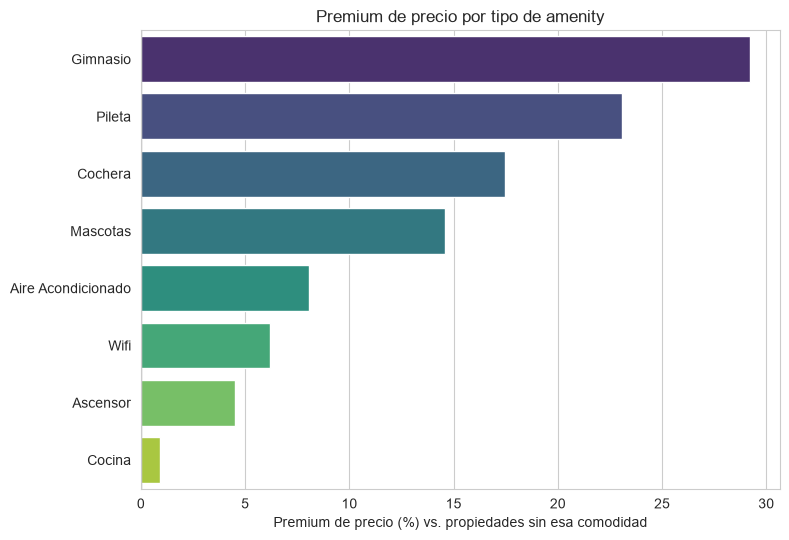

,amenity,precio_con,precio_sin,premium_pct
6,Gimnasio,153625.8,118908.0,29.2
1,Pileta,142848.1,116076.1,23.1
3,Cochera,131924.2,112317.4,17.5
7,Mascotas,137516.6,120034.0,14.6
2,Aire Acondicionado,126221.5,116821.7,8.0
0,Wifi,123410.0,116220.7,6.2
5,Ascensor,125476.1,120064.3,4.5
4,Cocina,123421.2,122277.0,0.9


In [11]:
amenities_cols = list(amenities_clave.keys())
premium = []
for col in amenities_cols:
    con = df_analisis.loc[df_analisis[col], "price_clean"].mean()
    sin = df_analisis.loc[~df_analisis[col], "price_clean"].mean()
    premium.append({
        "amenity": col.replace("tiene_", "").replace("acepta_", "").replace("_", " ").title(),
        "precio_con": con,
        "precio_sin": sin,
        "premium_pct": (con / sin - 1) * 100,
    })
premium_df = pd.DataFrame(premium).sort_values("premium_pct", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.barplot(data=premium_df, y="amenity", x="premium_pct", hue="amenity", palette="viridis", legend=False, ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Premium de precio (%) vs. propiedades sin esa comodidad")
ax.set_ylabel("")
ax.set_title("Premium de precio por tipo de amenity")
plt.tight_layout()
plt.savefig("data/fig_premium_amenities.png", dpi=150)
plt.show()

premium_df.round(1)


**Lectura:** cada barra muestra cuánto más caras son, en promedio, las propiedades que
ofrecen esa comodidad frente a las que no la ofrecen. Comodidades con premium alto y baja
penetración (pocas propiedades la ofrecen) son las mejores candidatas a inversión con retorno
más claro.


### 3.4 Contexto adicional: distribución de precios y tipo de propiedad


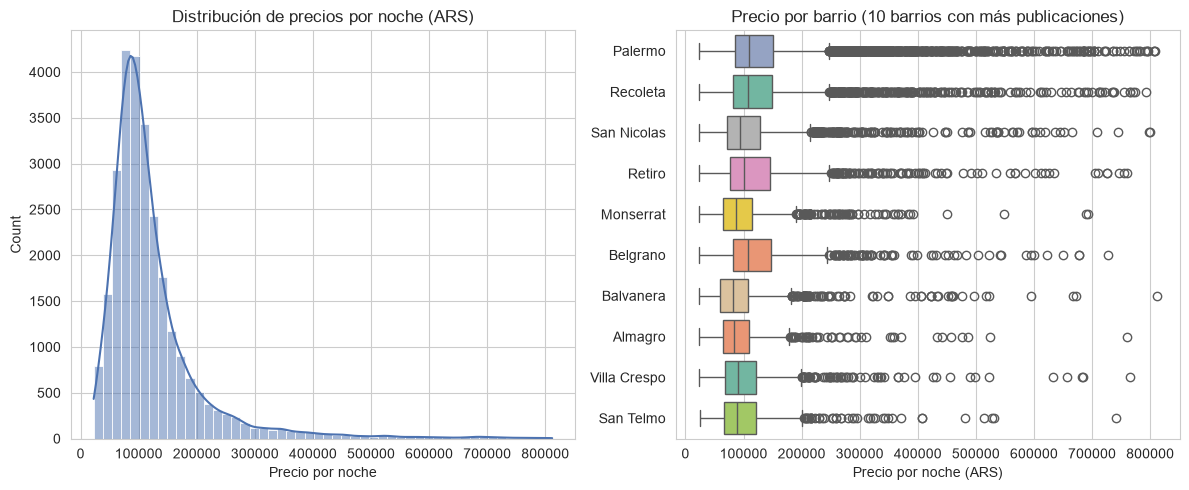

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_analisis["price_clean"], bins=50, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribución de precios por noche (ARS)")
axes[0].set_xlabel("Precio por noche")

top_barrios = df_analisis["barrio"].value_counts().head(10).index
sns.boxplot(
    data=df_analisis[df_analisis["barrio"].isin(top_barrios)],
    x="price_clean", y="barrio", hue="barrio", palette="Set2", legend=False,
    order=top_barrios, ax=axes[1],
)
axes[1].set_title("Precio por barrio (10 barrios con más publicaciones)")
axes[1].set_xlabel("Precio por noche (ARS)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("data/fig_distribucion_precio.png", dpi=150)
plt.show()


## 4. Insights / Conclusiones

**Pregunta 1 — Densidad de puntos de interés vs. precio:**
Los barrios con mayor concentración de restaurantes, bares y opciones de transporte público en
un radio de 900 metros muestran, en promedio, tarifas más altas por noche (ver correlación
calculada en 3.1). Para un inversor, esto sugiere que la "caminabilidad" del barrio hacia oferta
gastronómica y transporte es un factor de pricing tan relevante como el tamaño o tipo de la
propiedad.

**Pregunta 2 — Reviews vs. tarifa promedio:**
La relación entre puntaje de reviews y precio es más débil y ruidosa de lo que la intuición
sugiere (ver 3.2): un buen puntaje es casi una condición necesaria para sostenerse en el
mercado, pero no explica por sí solo tarifas más altas. El puntaje de "ubicación" dentro de las
reviews tiende a moverse más en línea con el precio que el puntaje general.

**Pregunta 3 — Premium por amenities:**
No todas las comodidades valen lo mismo. Las amenities con mayor premium de precio (ver 3.3) son
las que conviene priorizar al equipar una propiedad nueva, especialmente si tienen baja
penetración en el mercado actual (pocos competidores las ofrecen todavía).

**Recomendación para la audiencia (inversores / gestores de alquiler temporario):**
Priorizar barrios con alta densidad de oferta gastronómica y transporte, mantener un puntaje de
reviews saludable como piso no negociable, e invertir selectivamente en las amenities de mayor
premium relativo antes que en amenities "de moda" mal aprovechadas por el mercado.

*Nota metodológica: este análisis es exploratorio y descriptivo (correlaciones), no causal. La
segunda entrega del TP incorporará modelos de Machine Learning entrenados y optimizados para
predecir precio y ocupación, y así cuantificar el efecto de cada variable de forma más rigurosa.*


## Anexo: Conexión con Google Analytics 4 (requisito de cátedra)

Este bloque no forma parte del análisis de Airbnb (que usa Inside Airbnb + OpenStreetMap, ver
Sección 1). Se incluye para acreditar el requisito, mencionado en clase, de establecer una
conexión funcional con **Google Analytics 4** desde el notebook.

Como este proyecto no cuenta con un sitio o app propia instrumentada con GA4, la conexión se
realiza contra la **exportación pública de GA4 a BigQuery** que Google publica para fines
educativos (`bigquery-public-data.ga4_obfuscated_sample_ecommerce`): son eventos reales de GA4
(page_view, session_start, add_to_cart, purchase, etc.) de una tienda de e-commerce, con la
misma estructura que exporta cualquier propiedad de Google Analytics 4 real.

**Para ejecutar esta celda:**
1. Se necesita un proyecto de Google Cloud (gratuito, sin tarjeta) con la API de BigQuery
   habilitada — ya está creado: `tp-ds2-ga4-airbnb`.
2. Al correr la celda en Google Colab, `auth.authenticate_user()` abre un login interactivo
   con tu cuenta de Google. Fuera de Colab (por ejemplo, Jupyter local) la celda detecta el
   entorno y no intenta autenticar.


In [13]:
try:
    from google.colab import auth
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

GA4_PROJECT_ID = "tp-ds2-ga4-airbnb"  # proyecto de Google Cloud (Zona de pruebas, sin facturacion)

if IN_COLAB:
    auth.authenticate_user()
    from google.cloud import bigquery

    client = bigquery.Client(project=GA4_PROJECT_ID)

    query_ga4 = """
    SELECT
      event_date,
      event_name,
      COUNT(*) AS eventos
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_20210131`
    GROUP BY event_date, event_name
    ORDER BY eventos DESC
    LIMIT 10
    """
    ga4_eventos = client.query(query_ga4).to_dataframe()
    print("Conexion con Google Analytics 4 (BigQuery) establecida correctamente.")
    display(ga4_eventos)
else:
    print(
        "Esta celda se conecta a Google Analytics 4 via BigQuery y requiere un entorno "
        "de Google Colab (usa google.colab.auth para el login interactivo). "
        "Ejecutar este notebook en Colab para ver la conexion en accion."
    )


Esta celda se conecta a Google Analytics 4 via BigQuery y requiere un entorno de Google Colab (usa google.colab.auth para el login interactivo). Ejecutar este notebook en Colab para ver la conexion en accion.


**Lectura:** la tabla muestra los 10 tipos de evento de GA4 más frecuentes en un día de
la tienda de referencia (page_view, user_engagement, scroll, session_start, etc.), confirmando
que la conexión con la API/exportación de Google Analytics 4 está establecida y devuelve datos
reales.
